In [ ]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

In [ ]:
aq_clean_path=os.path.join('data', 'processed', 'air_quality_clean.csv')
df_air=pd.read_csv(os.path.abspath(aq_clean_path))

ben_clean_path=os.path.join('data', 'processed', 'NYNY_BenMAP_clean.csv')
df_ben=pd.read_csv(os.path.abspath(ben_clean_path))

In [ ]:
df_air_borough=df_air[df_air['Geo Type Name']=='Borough']

In [ ]:
df_air_borough_a=df_air_borough[(df_air_borough['Name']=='Nitrogen dioxide (NO2)')|(df_air_borough['Name']=='Ozone (O3)')|(df_air_borough['Name']=='Fine particles (PM 2.5)')]

In [ ]:
df_air_borough_b=df_air_borough_a[['Indicator ID', 'Name', 'Measure Info', 'Geo Place Name', 'Data Value']]

In [ ]:
df_air_borough_b_group=df_air_borough_b.groupby(['Indicator ID', 'Name', 'Measure Info', 'Geo Place Name']).mean().sort_values('Geo Place Name').reset_index()

In [ ]:
df_ben_a=df_ben[['bgrp', 'NO2_Acute_Respiratory_Symptoms_I', 'O3_Acute_Respiratory_Symptoms_I', 'PM25_Acute_Respiratory_Symptoms_I']]

In [ ]:
def get_borough_from_bgrp(bgrp):
    if 360050000000 <= bgrp <= 360059999999:
        return 'Bronx'
    elif 360470000000 <= bgrp <= 360479999999:
        return 'Brooklyn'
    elif 360610000000 <= bgrp <= 360619999999:
        return 'Manhattan'
    elif 360810000000 <= bgrp <= 360819999999:
        return 'Queens'
    elif 360850000000 <= bgrp <= 360859999999:
        return 'Staten Island'

df_ben_b=df_ben_a.copy()
df_ben_b['Borough'] = df_ben_b['bgrp'].apply(get_borough_from_bgrp)

In [ ]:
ben_new_order=['bgrp', 'Borough', 'NO2_Acute_Respiratory_Symptoms_I', 'O3_Acute_Respiratory_Symptoms_I', 'PM25_Acute_Respiratory_Symptoms_I']
df_ben_b=df_ben_b[ben_new_order]

In [ ]:
no_brgp=['Borough', 'NO2_Acute_Respiratory_Symptoms_I', 'O3_Acute_Respiratory_Symptoms_I', 'PM25_Acute_Respiratory_Symptoms_I']
df_ben_b_group=df_ben_b[no_brgp].groupby('Borough').sum().reset_index()

In [ ]:
df_ben_melted = pd.melt(df_ben_b_group, id_vars=['Borough'],
                        value_vars=['NO2_Acute_Respiratory_Symptoms_I', 'O3_Acute_Respiratory_Symptoms_I', 'PM25_Acute_Respiratory_Symptoms_I'],
                        var_name='Symptom Type', value_name='Symptom Value')
df_ben_melted = df_ben_melted.rename(columns={'Borough': 'Geo Place Name'})

symptom_name_mapping = {
    'NO2_Acute_Respiratory_Symptoms_I': 'Nitrogen dioxide (NO2)',
    'O3_Acute_Respiratory_Symptoms_I': 'Ozone (O3)',
    'PM25_Acute_Respiratory_Symptoms_I': 'Fine particles (PM 2.5)'
}
df_ben_melted['Name'] = df_ben_melted['Symptom Type'].map(symptom_name_mapping)

In [ ]:
df_merged = pd.merge(df_air_borough_b_group, df_ben_melted, on=['Geo Place Name', 'Name'], how='inner')
df_merged=df_merged[['Geo Place Name', 'Indicator ID', 'Name', 'Measure Info', 'Data Value', 'Symptom Type', 'Symptom Value']].sort_values(['Geo Place Name', 'Symptom Type']). reset_index(drop=True)
df_merged=df_merged.rename(columns={'Data Value': 'Mean Measure Value'})
df_merged.to_csv(os.path.abspath('data/processed/merged.csv'), index=False)

In [ ]:
df_merged_no2=df_merged[df_merged['Name']=='Nitrogen dioxide (NO2)']
df_merged_o3=df_merged[df_merged['Name']=='Ozone (O3)']
df_merged_pm=df_merged[df_merged['Name']=='Fine particles (PM 2.5)']

In [ ]:
no2_corr=df_merged_no2['Mean Measure Value'].corr(df_merged_no2['Symptom Value'])
o3_corr=df_merged_o3['Mean Measure Value'].corr(df_merged_o3['Symptom Value'])
pm_corr=df_merged_pm['Mean Measure Value'].corr(df_merged_pm['Symptom Value'])

In [ ]:
correlations_df = pd.DataFrame({
    'Correlation': [o3_corr, no2_corr, pm_corr]
}, index=['Ozone (O3)', 'Nitrogen dioxide (NO2)', 'Fine particles (PM 2.5)'])

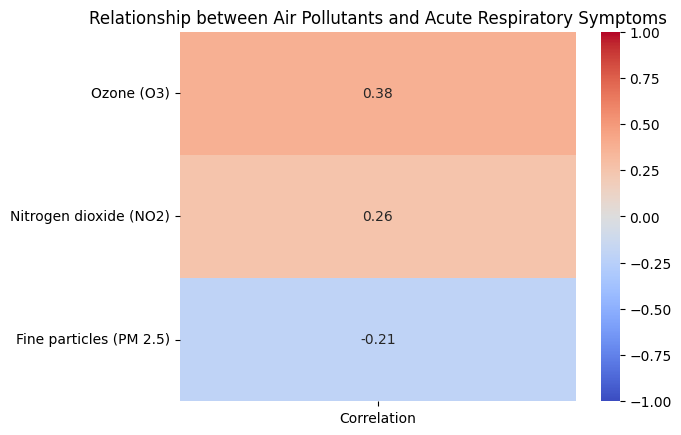

In [ ]:
sns.heatmap(correlations_df, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Relationship between Air Pollutants and Acute Respiratory Symptoms')
plt.savefig('correlation.png', bbox_inches='tight')
plt.show()